# Load imports and the events

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os.path
import json

# 3433 matches with events logged
# 3433 lineups

# test loading of one json file to events list

with open('data/events/7298.json', 'r') as match:
    match1 = []
    events = json.load(match)
    for item in events:
        match1.append(item)

len(match1)

3793

In [4]:
# convert events list to pandas dataframe
import pandas as pd

matchEventDf = pd.DataFrame(match1)
matchEventDf.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3793 entries, 0 to 3792
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3793 non-null   object 
 1   index            3793 non-null   int64  
 2   period           3793 non-null   int64  
 3   timestamp        3793 non-null   object 
 4   minute           3793 non-null   int64  
 5   second           3793 non-null   int64  
 6   type             3793 non-null   object 
 7   possession       3793 non-null   int64  
 8   possession_team  3793 non-null   object 
 9   play_pattern     3793 non-null   object 
 10  team             3793 non-null   object 
 11  duration         2347 non-null   float64
 12  tactics          5 non-null      object 
 13  related_events   3600 non-null   object 
 14  player           3756 non-null   object 
 15  position         3756 non-null   object 
 16  location         3744 non-null   object 
 17  pass          

In [5]:
allPassesInMatch = matchEventDf.copy().dropna(subset=['pass'])
allPassesInMatch.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 4 to 3789
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1000 non-null   object 
 1   index            1000 non-null   int64  
 2   period           1000 non-null   int64  
 3   timestamp        1000 non-null   object 
 4   minute           1000 non-null   int64  
 5   second           1000 non-null   int64  
 6   type             1000 non-null   object 
 7   possession       1000 non-null   int64  
 8   possession_team  1000 non-null   object 
 9   play_pattern     1000 non-null   object 
 10  team             1000 non-null   object 
 11  duration         1000 non-null   float64
 12  tactics          0 non-null      object 
 13  related_events   994 non-null    object 
 14  player           1000 non-null   object 
 15  position         1000 non-null   object 
 16  location         1000 non-null   object 
 17  pass             10

In [6]:
currentRecord = allPassesInMatch.iloc[0]
print(currentRecord["timestamp"])
print(currentRecord["possession"])
print(currentRecord["play_pattern"])
print(currentRecord["team"])
print(currentRecord["duration"])
print(currentRecord["player"])
print(currentRecord["position"])
print(currentRecord["location"])
print(currentRecord["pass"])
print(currentRecord["under_pressure"])

00:00:00.100
2
{'id': 9, 'name': 'From Kick Off'}
{'id': 971, 'name': 'Chelsea FCW'}
0.0
{'id': 4647, 'name': 'So-Yun Ji'}
{'id': 14, 'name': 'Center Midfield'}
[61.0, 40.0]
{'recipient': {'id': 4659, 'name': 'Ramona Bachmann'}, 'length': 3.6055512, 'angle': -0.98279375, 'height': {'id': 1, 'name': 'Ground Pass'}, 'end_location': [63.0, 37.0], 'body_part': {'id': 40, 'name': 'Right Foot'}, 'type': {'id': 65, 'name': 'Kick Off'}}
nan


In [7]:
def getAllShotsInMatch(matchEventDf):
    df = matchEventDf.copy()
    df.drop(['ball_receipt', 'ball_recovery', 'block', 'carry', 'counterpress', 'dribble', 'duel', 'foul_committed', 'foul_won', 'goalkeeper', 'injury_stoppage', 'interception', 'pass', 'substitution', 'tactics', 'type', 'bad_behaviour'], axis=1, inplace=True)
    return df.dropna(subset=['shot'])

allShotsInMatch = getAllShotsInMatch(matchEventDf)

allShotsInMatch.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, 41 to 3735
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               34 non-null     object 
 1   index            34 non-null     int64  
 2   period           34 non-null     int64  
 3   timestamp        34 non-null     object 
 4   minute           34 non-null     int64  
 5   second           34 non-null     int64  
 6   possession       34 non-null     int64  
 7   possession_team  34 non-null     object 
 8   play_pattern     34 non-null     object 
 9   team             34 non-null     object 
 10  duration         34 non-null     float64
 11  related_events   34 non-null     object 
 12  player           34 non-null     object 
 13  position         34 non-null     object 
 14  location         34 non-null     object 
 15  under_pressure   7 non-null      object 
 16  shot             34 non-null     object 
dtypes: float64(1), int64

In [8]:
allShotsInMatch.iloc[0]

id                              9b82eaa3-2048-4157-aa9a-eabeb4fa0ebe
index                                                             42
period                                                             1
timestamp                                               00:00:47.620
minute                                                             0
second                                                            47
possession                                                         4
possession_team                   {'id': 971, 'name': 'Chelsea FCW'}
play_pattern                       {'id': 6, 'name': 'From Counter'}
team                              {'id': 971, 'name': 'Chelsea FCW'}
duration                                                        0.56
related_events     [a1c408ce-f949-4dfd-801f-08ed281da0cc, e3be7cc...
player                       {'id': 4641, 'name': 'Francesca Kirby'}
position                  {'id': 22, 'name': 'Right Center Forward'}
location                          

In [9]:
allShotsInMatch.iloc[0]["shot"]

{'statsbomb_xg': 0.018856188,
 'end_location': [117.0, 34.0],
 'key_pass_id': '00821d9b-c6c8-4c05-9b81-3cb1bba0e845',
 'body_part': {'id': 40, 'name': 'Right Foot'},
 'technique': {'id': 93, 'name': 'Normal'},
 'type': {'id': 87, 'name': 'Open Play'},
 'outcome': {'id': 96, 'name': 'Blocked'},
 'freeze_frame': [{'location': [97.0, 48.0],
   'player': {'id': 17275, 'name': 'Hannah Jayne Blundell'},
   'position': {'id': 12, 'name': 'Right Midfield'},
   'teammate': True},
  {'location': [113.0, 38.0],
   'player': {'id': 4638, 'name': 'Drew Spence'},
   'position': {'id': 15, 'name': 'Left Center Midfield'},
   'teammate': True},
  {'location': [112.0, 28.0],
   'player': {'id': 4649, 'name': 'Esme Beth Morgan'},
   'position': {'id': 2, 'name': 'Right Back'},
   'teammate': False},
  {'location': [103.0, 50.0],
   'player': {'id': 4635, 'name': 'Julia Spetsmark'},
   'position': {'id': 21, 'name': 'Left Wing'},
   'teammate': False},
  {'location': [120.0, 26.0],
   'player': {'id': 46

In [10]:
def getPlayerPositionsDuringShots(shot):
    frame = shot["freeze_frame"]
    otherPlayerPositions = []

    for player in frame:
        playerDict = {}
        playerDict["location"] = player["location"]
        playerDict["position"] = player["position"]["name"]
        playerDict["teammate"] = player["teammate"]
        otherPlayerPositions.append(playerDict)
    
    return otherPlayerPositions

def addToDict(record, dictionary, cols):
    for col in cols:
        dictionary[col] = record[col] if col in record else None

#shot dataframe
shotDfCols = ["end_location", "aerial_won", "follows_dribble", "first_time", "open_goal", "deflected", "body_part", "type", "technique", "outcome", "statsbomb_xg"]
shotRowDfCols = ["player", "position", "location", "under_pressure"]
shotCompositeDfCols = ["player_positions"]

# shotAnalysisDf = pd.DataFrame(columns=(shotDfCols + shotRowDfCols + shotCompositeDfCols))
listOfShots = []

for row in allShotsInMatch.iloc:
    shot = row["shot"]

    shotDict = {}
    addToDict(shot, shotDict, shotDfCols)
    addToDict(row, shotDict, shotRowDfCols)

    shotDict["type"] = shot["type"]["name"]
    shotDict["body_part"] = shot["body_part"]["name"]
    shotDict["technique"] = shot["technique"]["name"]
    shotDict["outcome"] = shot["outcome"]["name"]

    shotDict["player_positions"] = getPlayerPositionsDuringShots(shot)

    listOfShots.append(shotDict)

shotAnalysisDf = pd.DataFrame(listOfShots)


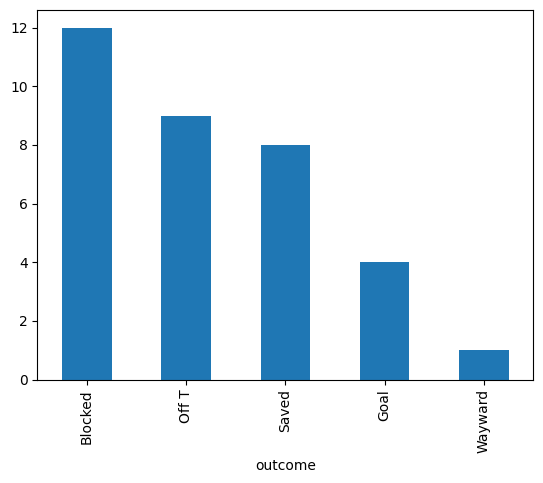

In [11]:
import matplotlib.pyplot as plt

shotAnalysisDf["outcome"].value_counts().plot(kind='bar')
plt.show()

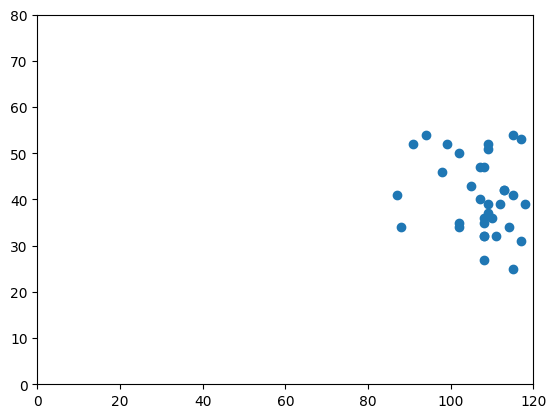

In [12]:
# scatter plot of shots
shotLocations = shotAnalysisDf["location"]

shotX = [loc[0] for loc in shotLocations]
shotY = [loc[1] for loc in shotLocations]

# set up x-axis from 0 to 120 and y-axis from 0 to 80
plt.xlim(0, 120)
plt.ylim(0, 80)

plt.scatter(shotX, shotY)
plt.show()


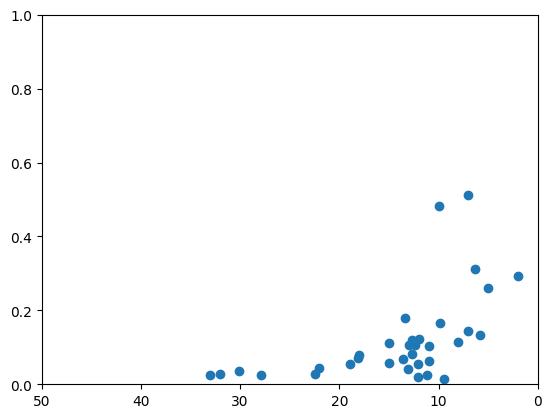

In [13]:
import numpy as np
from numpy.linalg import norm

import math

def distFromGoalLine(x3, y3): # x3,y3 is the point
    u =  ((y3 - 36) * 8) / float(64)

    if u > 1:
        u = 1
    elif u < 0:
        u = 0

    x = 120
    y = 36 + u * 8

    dx = x - x3
    dy = y - y3

    # Note: If the actual distance does not matter,
    # if you only want to compare what this function
    # returns to other results of this function, you
    # can just return the squared distance instead
    # (i.e. remove the sqrt) to gain a little performance

    dist = (dx*dx + dy*dy)**.5

    return dist

shotDistances = [distFromGoalLine(loc[0], loc[1]) for loc in shotLocations]
shotXg = shotAnalysisDf["statsbomb_xg"]

plt.xlim(50, 0)
plt.ylim(0, 1)

plt.scatter(shotDistances, shotXg)
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

# shot distance to calculate xG - create test and train sets
X = np.array(shotDistances).reshape(-1, 1)
y = np.array(shotXg)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


[0.02452622 0.10323378 0.18030268 0.5121269  0.11130494 0.16594568
 0.03513363]
[-0.00117538  0.12991797  0.1117071   0.16102554  0.0988104   0.13887028
 -0.01849018]
RMSE: 0.1378999852136325
% error: 59.63032706203136


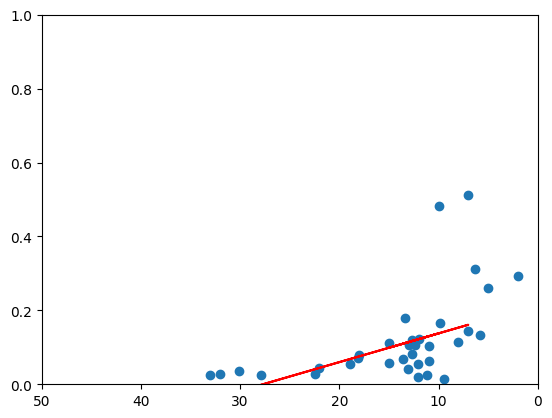

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

def percentage_error(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

y_pred = linear_reg.predict(X_test)

rmse_linear_reg = root_mean_squared_error(y_test, y_pred)
pe_linear_reg = percentage_error(y_test, y_pred)

print(y_test)
print(y_pred)
print("RMSE:", rmse_linear_reg)
print("% error:", pe_linear_reg)

plt.xlim(50, 0)
plt.ylim(0, 1)

plt.scatter(X, y)
plt.plot(X_test, y_pred, color='red')
plt.show()

In [23]:
# create exponential model
fit = np.polyfit(shotDistances, np.log(shotXg), 1)

print(fit)

def graph(formula, x_range):
   x = np.arange(*x_range)
   y = eval(formula)
   plt.plot(x, y)

[-0.07600263 -1.44371316]


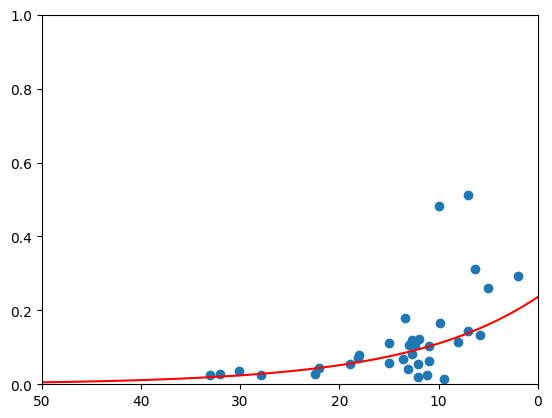

In [30]:
# ln y = -1.44371316 - 0.07600263x
# y = e^(-1.44371316) * e^(-0.07600263x)
plt.xlim(50, 0)
plt.ylim(0, 1)

# funct eval
exp_x = np.linspace(50, 0, 100)
exp_y = np.exp(-1.44371316 + -0.07600263 * exp_x)

plt.scatter(shotDistances, shotXg)
plt.plot(exp_x, exp_y, color='red')
plt.show()

In [35]:
exp_y_pred = np.exp(-1.44371316 + -0.07600263 * X_test)
rmse_exp_reg = root_mean_squared_error(y_test, exp_y_pred)
pe_exp_reg = percentage_error(y_test, exp_y_pred)

print("RMSE:", rmse_exp_reg)
print("% error:", pe_exp_reg)

RMSE: 0.14774965239018562
% error: 90.56841054216554


passmaps? xShotValue.